In [0]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, TimestampType
from datetime import datetime, timedelta
import random

# Иницијализација на Spark сесија
spark = SparkSession.builder.appName("SecurityLogAnalysis").getOrCreate()

# 1. Дефинирање на шема
schema = StructType([
    StructField("timestamp", TimestampType(), True),
    StructField("ip_address", StringType(), True),
    StructField("method", StringType(), True),
    StructField("url", StringType(), True),
    StructField("status_code", IntegerType(), True)
])

# 2. Податоци за симулација
ips = ["192.168.1.10", "10.0.0.5", "45.33.22.11", "88.12.34.56"]
urls = ["/home", "/login", "/api/v1/users"]
malicious = ["/products?id=1' OR '1'='1", "/etc/passwd", "<script>alert(1)</script>"]

data = []
for i in range(100):
    url = random.choice(malicious) if i % 10 == 0 else random.choice(urls)
    data.append((datetime.now() + timedelta(seconds=i), random.choice(ips), "GET", url, 200))

# Креирање на DataFrame
df = spark.createDataFrame(data, schema)
df.show(10, truncate=False)

+--------------------------+------------+------+-------------------------+-----------+
|timestamp                 |ip_address  |method|url                      |status_code|
+--------------------------+------------+------+-------------------------+-----------+
|2026-03-19 22:20:51.274872|10.0.0.5    |GET   |/products?id=1' OR '1'='1|200        |
|2026-03-19 22:20:52.274887|45.33.22.11 |GET   |/home                    |200        |
|2026-03-19 22:20:53.274895|88.12.34.56 |GET   |/home                    |200        |
|2026-03-19 22:20:54.274901|192.168.1.10|GET   |/login                   |200        |
|2026-03-19 22:20:55.274908|10.0.0.5    |GET   |/home                    |200        |
|2026-03-19 22:20:56.274914|10.0.0.5    |GET   |/api/v1/users            |200        |
|2026-03-19 22:20:57.27492 |45.33.22.11 |GET   |/home                    |200        |
|2026-03-19 22:20:58.274926|45.33.22.11 |GET   |/api/v1/users            |200        |
|2026-03-19 22:20:59.274932|45.33.22.11 |GE

In [0]:
from pyspark.sql.functions import col, when

# 1. Скенирање на URL адресите за специфични знаци на хакерски напади
# 2. Означување на секој ред со соодветна категорија (Safe или напад)
silver_df = df.withColumn("security_status", 
    when(col("url").contains("' OR '1'='1") | col("url").contains("DROP"), "SQL Injection Attempt")
    .when(col("url").contains("<script>"), "XSS Attempt")
    .when(col("url").contains("/etc/passwd"), "Path Traversal Attempt")
    .otherwise("Safe")
)

# Да ги прикажеме само оние што СЕ напади за да провериме дали логиката работи
threats_df = silver_df.filter(col("security_status") != "Safe")

print("Детектирани безбедносни закани:")
threats_df.show(truncate=False)

Детектирани безбедносни закани:
+--------------------------+------------+------+-------------------------+-----------+----------------------+
|timestamp                 |ip_address  |method|url                      |status_code|security_status       |
+--------------------------+------------+------+-------------------------+-----------+----------------------+
|2026-03-19 22:20:51.274872|10.0.0.5    |GET   |/products?id=1' OR '1'='1|200        |SQL Injection Attempt |
|2026-03-19 22:21:01.274944|192.168.1.10|GET   |/products?id=1' OR '1'='1|200        |SQL Injection Attempt |
|2026-03-19 22:21:11.275193|10.0.0.5    |GET   |/products?id=1' OR '1'='1|200        |SQL Injection Attempt |
|2026-03-19 22:21:21.275249|45.33.22.11 |GET   |/products?id=1' OR '1'='1|200        |SQL Injection Attempt |
|2026-03-19 22:21:31.275304|45.33.22.11 |GET   |/products?id=1' OR '1'='1|200        |SQL Injection Attempt |
|2026-03-19 22:21:41.27536 |10.0.0.5    |GET   |/products?id=1' OR '1'='1|200        |SQ

In [0]:
# Групирање по IP адреса и тип на напад за да видиме кој е најактивен напаѓач
gold_report = silver_df.filter(col("security_status") != "Safe") \
    .groupBy("ip_address", "security_status") \
    .count() \
    .orderBy(col("count").desc())

print("Извештај: Топ напаѓачи по IP адреса:")
gold_report.show()

Извештај: Топ напаѓачи по IP адреса:
+------------+--------------------+-----+
|  ip_address|     security_status|count|
+------------+--------------------+-----+
|    10.0.0.5|SQL Injection Att...|    3|
| 45.33.22.11|SQL Injection Att...|    2|
| 88.12.34.56|Path Traversal At...|    2|
|192.168.1.10|SQL Injection Att...|    1|
|    10.0.0.5|         XSS Attempt|    1|
| 45.33.22.11|Path Traversal At...|    1|
+------------+--------------------+-----+



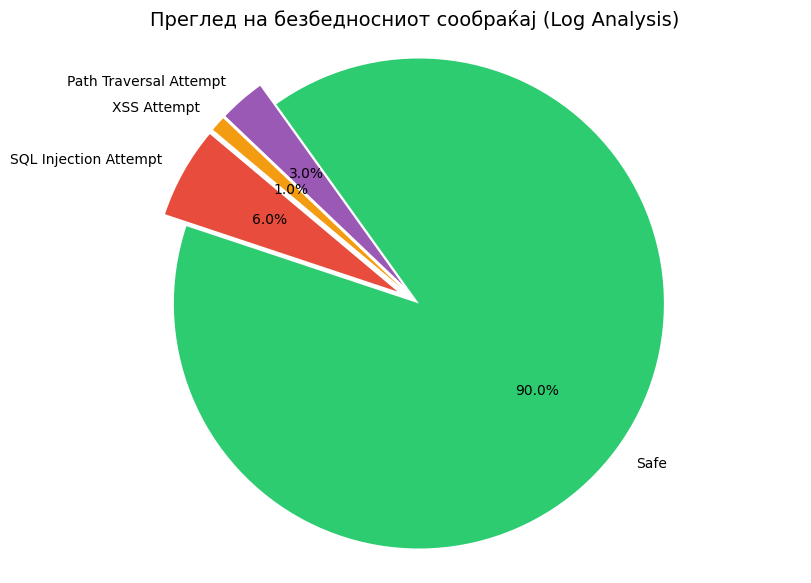

In [0]:
import matplotlib.pyplot as plt

# 1. Групирање на податоците за графиконот
# Го претвораме во Pandas DataFrame само за цртање (бидејќи се малку податоци на крај)
stats_pd = silver_df.groupBy("security_status").count().toPandas()

# 2. Дефинирање на бои (Зелена за безбедно, нијанси на црвено за напади)
colors_map = {
    "Safe": "#2ecc71", 
    "SQL Injection Attempt": "#e74c3c", 
    "XSS Attempt": "#f39c12", 
    "Path Traversal Attempt": "#9b59b6"
}
colors = [colors_map.get(status, "#95a5a6") for status in stats_pd['security_status']]

# 3. Цртање на графиконот
plt.figure(figsize=(10, 7))
plt.pie(stats_pd['count'], labels=stats_pd['security_status'], autopct='%1.1f%%', 
        colors=colors, startangle=140, explode=[0.1 if s != "Safe" else 0 for s in stats_pd['security_status']])

plt.title("Преглед на безбедносниот сообраќај (Log Analysis)", fontsize=14)
plt.axis('equal') 
plt.show()